In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [4]:
df = pd.read_csv('df_clean.csv')

In [5]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1,1.0,0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3,1,43.0,0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2,1,20.0,0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,1,15.0,0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0


In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

In [7]:
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

In [8]:
num_features = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
cat_features = ["male", "education", "currentSmoker", "BPMeds", "prevalentStroke",
                "prevalentHyp", "diabetes"]

In [9]:
num_transformer = SkPipeline(steps=[
    ("scaler", StandardScaler())
])

cat_transformer = SkPipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])



In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

In [11]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.35874439 0.36514523 0.33050847 0.3776824  0.3539823  0.36595745
 0.40758294 0.39069767 0.37037037 0.40930233]
Mean F1: 0.3729973557296812


In [12]:


recall_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="recall")
precision_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="precision")
roc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")

print("Mean Recall:", recall_scores.mean())
print("Mean Precision:", precision_scores.mean())
print("Mean ROC-AUC:", roc_scores.mean())

Mean Recall: 0.6584615384615384
Mean Precision: 0.2605955419204057
Mean ROC-AUC: 0.7187435579378258


In [13]:
accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
print("Mean Accuracy:", accuracy_scores.mean())

Mean Accuracy: 0.6625797314777644


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.001 ,0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0.1, 0.28,  0.3, 0.32,  0.5, 0.7, 0.9]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'model__C': 0.001, 'model__l1_ratio': 0.1}
Best score: 0.38077375401487124


In [15]:
best_model = grid.best_estimator_

print(best_model)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'cigsPerDay',
                                                   'totChol', 'sysBP', 'diaBP',
                                                   'BMI', 'heartRate',
                                                   'glucose']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['male', 'education',
                                                   'currentSmoker', 'BPMeds',
                                                   'prevalentStrok

In [16]:
accuracy_scores = cross_val_score(best_model, X, y, cv=cv, scoring="accuracy")
precision_scores = cross_val_score(best_model, X, y, cv=cv, scoring="precision")
recall_scores = cross_val_score(best_model, X, y, cv=cv, scoring="recall")
f1_scores = cross_val_score(best_model, X, y, cv=cv, scoring="f1")
roc_auc_scores = cross_val_score(best_model, X, y, cv=cv, scoring="roc_auc")

print("Mean Accuracy:", accuracy_scores.mean())
print("Mean Precision:", precision_scores.mean())
print("Mean Recall:", recall_scores.mean())
print("Mean F1:", f1_scores.mean())
print("Mean ROC-AUC:", roc_auc_scores.mean())

Mean Accuracy: 0.6691946563183013
Mean Precision: 0.2666126550592889
Mean Recall: 0.6678846153846154
Mean F1: 0.38077375401487124
Mean ROC-AUC: 0.7225304265841132


Confusion Matrix:
[[2406 1188]
 [ 214  430]]
True Negatives: 2406
False Positives: 1188
False Negatives: 214
True Positives: 430

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.77      3594
           1       0.27      0.67      0.38       644

    accuracy                           0.67      4238
   macro avg       0.59      0.67      0.58      4238
weighted avg       0.82      0.67      0.71      4238



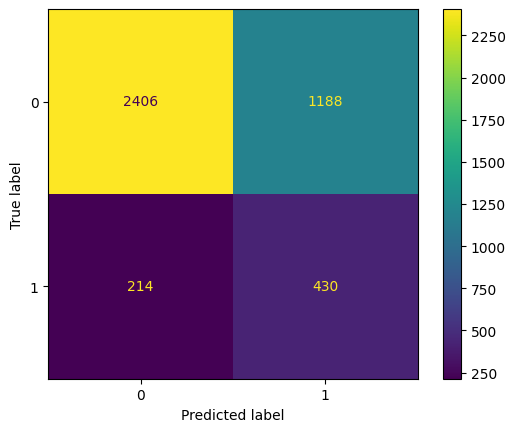

In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

best_model = grid.best_estimator_

y_pred = cross_val_predict(best_model, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nClassification Report:")
print(classification_report(y, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()